In [43]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import json

### Basic Meowfacts Data Orchestration

1.) Schedule `meowfact_collection_script` to run as a daily Airflow DAG using a PythonOperator

2.) Output resulting JSON into a GCS bucket

3.) Ingest new JSON files through a dbt pipeline using BigQuery. Clean / transform data as needed in this step.

4.) Take cleaned meowfact data and visualize in Looker

![alt text](meow_fact_flow.drawio.png)

In [45]:
# Setup for visualization

# Load the data script output
with open('daily_meowfact_data/meowfacts_data_20250702.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Convert to Pandas DataFrame
df = pd.DataFrame(data)

# Standardize Colors
languages = sorted(df['language'].unique())
cmap = plt.cm.get_cmap('tab20', len(languages))
language_colors = {lang: cmap(i) for i, lang in enumerate(languages)}

C:\Users\Keefer\AppData\Local\Temp\ipykernel_23156\3093911783.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(languages))


### Example visualizations

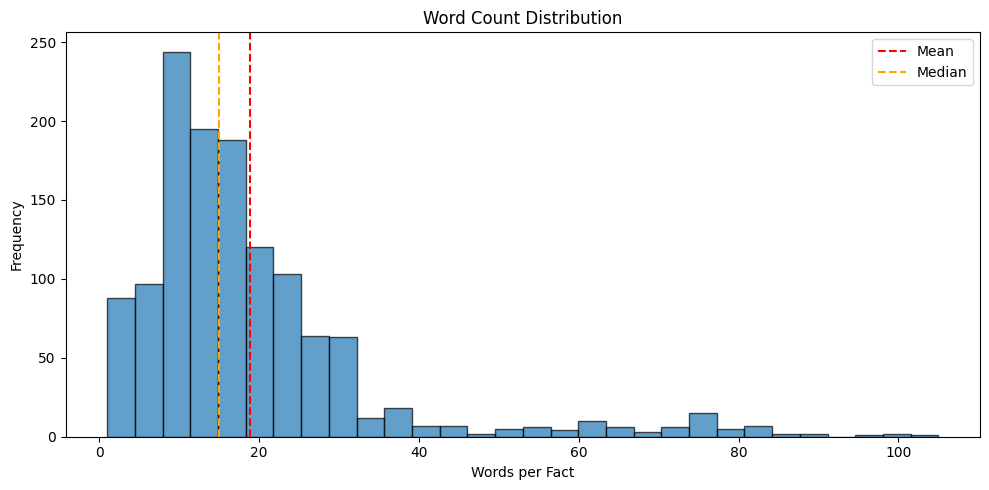

In [46]:
# Word Count Histogram

plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=30, edgecolor='black', alpha=0.7)

plt.axvline(df['word_count'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['word_count'].median(), color='orange', linestyle='--', label='Median')

plt.title('Word Count Distribution')
plt.xlabel('Words per Fact')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

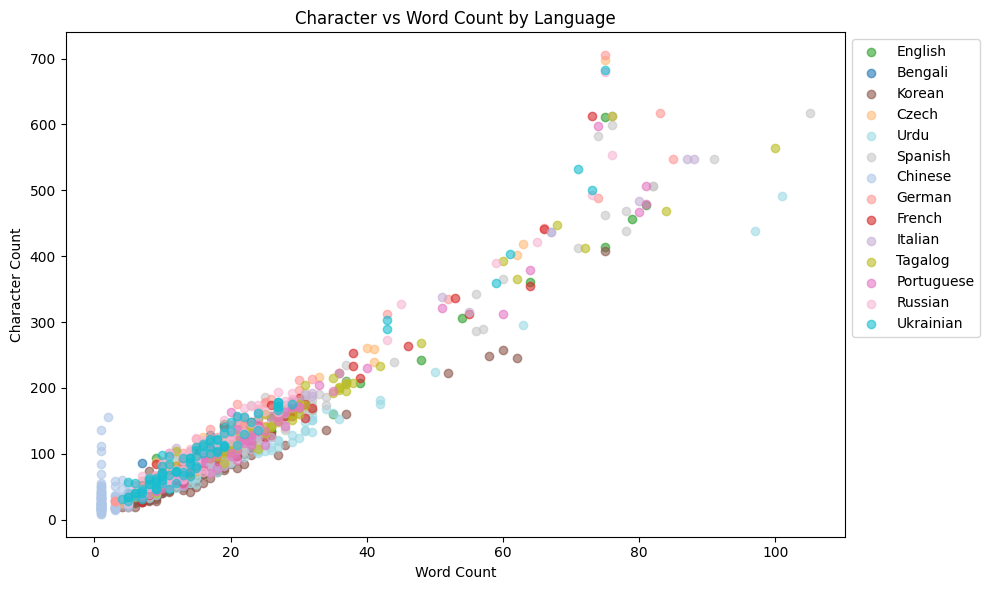

In [47]:
# Characters Word Count scatter plot

plt.figure(figsize=(10, 6))

for lang in df['language'].unique():
    data = df[df['language'] == lang]
    plt.scatter(data['word_count'], data['character_count'], label=lang, alpha=0.6, color=language_colors[lang])

plt.title('Character vs Word Count by Language')
plt.xlabel('Word Count')
plt.ylabel('Character Count')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

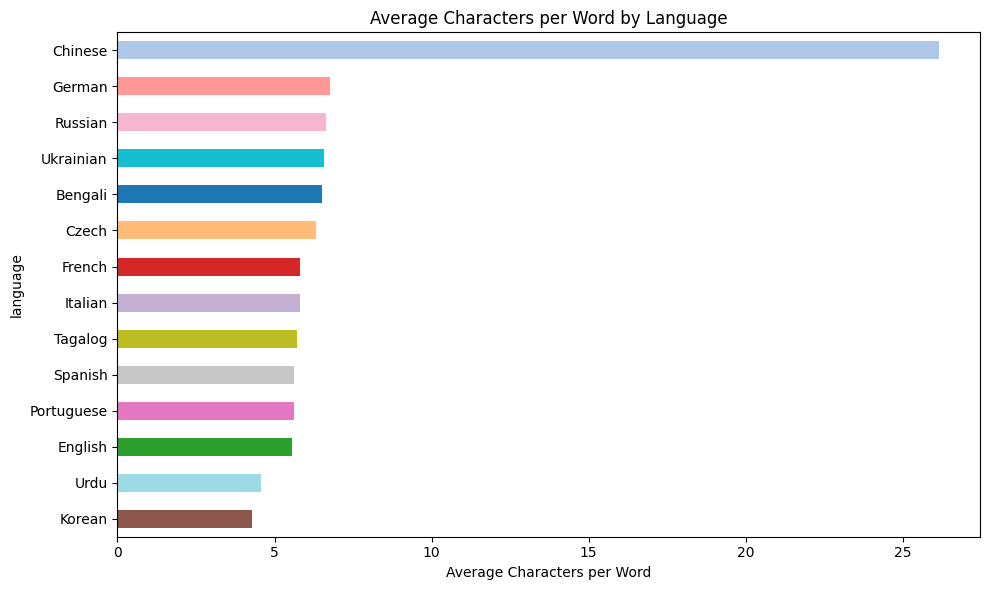

In [48]:
# Characters by word bar chart
df['chars_per_word'] = df['character_count'] / df['word_count']
avg_chars_per_word = df.groupby('language')['chars_per_word'].mean().sort_values()

bar_colors = [language_colors[lang] for lang in avg_chars_per_word.index]

plt.figure(figsize=(10, 6))
avg_chars_per_word.plot(kind='barh', color=bar_colors)
plt.xlabel('Average Characters per Word')
plt.title('Average Characters per Word by Language')
plt.tight_layout()
plt.show()